## Conditional Diffusion baseline

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import functools
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST, CIFAR10, FashionMNIST # Added FashionMNIST here
from tqdm.notebook import trange, tqdm
from torch.optim.lr_scheduler import MultiplicativeLR, LambdaLR
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from einops import rearrange
import math
from torch import einsum
device = "cuda" if torch.cuda.is_available() else "cpu"

## Fashion-MNIST dataset preprocessing

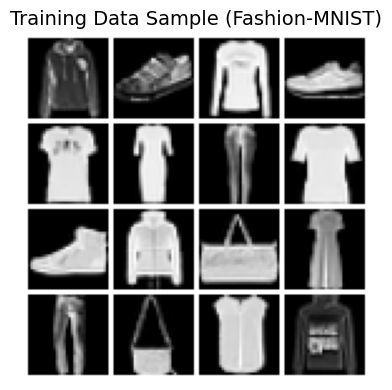

In [2]:
# Fashion-MNIST class names (matches ConditionalGanStabilization style)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1] for grayscale Fashion-MNIST
])

train_dataset = FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = FashionMNIST(root="./data", train=False, transform=transform, download=True)

dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Visualize a batch (style aligned with ConditionalGanStabilization)
images, labels = next(iter(dataloader))
grid = make_grid(images[:16], nrow=4, normalize=False, pad_value=1)
plt.figure(figsize=(10, 4))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5, cmap='gray')
plt.title("Training Data Sample (Fashion-MNIST)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## Model implementation: U-Net with Spatial Transformer for Conditioning


## Diffusion Process
SimpleDiffusion calculates the necessary beta and alpha values for the diffusion process and supports functions for sampling timesteps, adding noise to images, and running the reverse diffusion process to generate new images.

The sample method iteratively denoises random noise to generate an image.

In [3]:
class SimpleDiffusion:
    def __init__(self, num_diffusion_timesteps, img_shape, device):
        self.num_diffusion_timesteps = num_diffusion_timesteps
        self.img_shape = img_shape
        self.device = device

        self.betas = torch.linspace(1e-4, 0.02, num_diffusion_timesteps).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.num_diffusion_timesteps, size=(n,)).to(self.device)

    def noise_images(self, x, t):
        sqrt_alpha_bar = torch.sqrt(self.alpha_bars[t])[:, None, None, None]
        sqrt_one_minus_alpha_bar = torch.sqrt(1 - self.alpha_bars[t])[:, None, None, None]
        epsilon = torch.randn_like(x)
        return sqrt_alpha_bar * x + sqrt_one_minus_alpha_bar * epsilon, epsilon

    def sample(self, model, n, labels=None):
        model.eval()
        with torch.no_grad():
            x = torch.randn((n, *self.img_shape)).to(self.device)
            for i in tqdm(reversed(range(1, self.num_diffusion_timesteps)), position=0):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t, labels)
                alpha = self.alphas[t][:, None, None, None]
                alpha_bar = self.alpha_bars[t][:, None, None, None]
                beta = self.betas[t][:, None, None, None]
                if i > 1:
                    noise = torch.randn_like(x)
                else:
                    noise = torch.zeros_like(x)
                # DDPM reverse step; add small epsilon for numerical stability
                eps = 1e-8
                x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_bar + eps))) * predicted_noise) + torch.sqrt(beta) * noise
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        x = (x * 255).type(torch.uint8)
        return x

## Helper classes
This block defines various commonly used building blocks, such as residual connections, positional embeddings, attention mechanisms, and convolutions.

In [4]:
class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

def Upsample(dim):
    return nn.ConvTranspose2d(dim, dim, 4, 2, 1)

def Downsample(dim):
    return nn.Conv2d(dim, dim, 4, 2, 1)

class LayerNorm(nn.Module):
    def __init__(self, dim, eps = 1e-5):
        super().__init__()
        self.eps = eps
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
        self.b = nn.Parameter(torch.zeros(1, dim, 1, 1))

    def forward(self, x):
        var = torch.var(x, dim = 1, unbiased = False, keepdim = True)
        mean = torch.mean(x, dim = 1, keepdim = True)
        return (x - mean) / (var + self.eps).sqrt() * self.g + self.b

class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = LayerNorm(dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)

class ConvBlock(nn.Sequential):
    def __init__(self, in_channel, out_channel, kern_size, padd, groups, downsample = True, use_act = True):
        super().__init__()
        self.add_module('conv', nn.Conv2d(in_channel, out_channel, kern_size, stride = 2 if downsample else 1, padding = padd, groups = groups))
        self.add_module('norm', nn.GroupNorm(groups, out_channel))
        self.add_module('act', nn.SiLU() if use_act else nn.Identity())

class ResnetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, *, time_emb_dim = None, groups = 8, downsample = False):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        ) if time_emb_dim is not None else None

        self.block1 = ConvBlock(in_channels, out_channels, 3, 1, groups, downsample=downsample)
        self.block2 = ConvBlock(out_channels, out_channels, 3, 1, groups, downsample = False, use_act = False)

        if in_channels != out_channels or downsample:
            self.res_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2 if downsample else 1)
        else:
            self.res_conv = nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, time_emb = None):
        res = self.res_conv(x)

        h = self.block1(x)
        if self.mlp is not None and time_emb is not None:
            time_emb = self.mlp(time_emb)
            h = h + time_emb[:, :, None, None]
        h = self.act(h)
        h = self.block2(h)

        return h + res

class Attention(nn.Module):
    def __init__(self, dim, heads = 4, dim_head = 32):
        super().__init__()
        self.scale = dim_head ** -0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias = False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim = 1)
        q, k, v = map(lambda t: rearrange(t, 'b (h c) x y -> b h c (x y)', h = self.heads), qkv)
        sim = einsum('b h d i, b h d j -> b h i j', q, k) * self.scale
        sim = sim - sim.amax(dim = -1, keepdim = True).detach()
        attn = sim.softmax(dim = -1)
        out = einsum('b h i j, b h d j -> b h i d', attn, v)
        out = rearrange(out, 'b h (x y) d -> b (h d) x y', x = h, y = w)
        return self.to_out(out)

class LinearAttention(nn.Module):
    def __init__(self, dim, heads = 4, dim_head = 32):
        super().__init__()
        self.scale = dim_head ** -0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias = False)

        self.to_out = nn.Sequential(
            nn.Conv2d(hidden_dim, dim, 1),
            LayerNorm(dim)
        )

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim = 1)
        q, k, v = map(lambda t: rearrange(t, 'b (h c) x y -> b h c (x y)', h = self.heads), qkv)

        q = q.softmax(dim = -2)
        k = k.softmax(dim = -1)

        q = q * self.scale
        context = torch.einsum('b h d n, b h e n -> b h d e', k, v)

        out = torch.einsum('b h d e, b h d n -> b h e n', context, q)
        out = rearrange(out, 'b h c (x y) -> b (h c) x y', h = self.heads, x = h, y = w)
        return self.to_out(out)

## U-Net Architecture with Time and Class Conditioning
U-Net architecture consists of Time Embeddings, Downsampling Path, Bottleneck, Upsampling Path, Final Layers, and Class Conditioning.

In [5]:
class Unet(nn.Module):
    def __init__(self):
        super().__init__()

        # time embeddings
        time_dim = 32 * 4
        self.time_mlp =  nn.Sequential(
            SinusoidalPosEmb(32),
            nn.Linear(32, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim)
        )

        # initial conv
        self.init_conv = nn.Conv2d(1, 32, kernel_size=1) # Changed input channels to 1 for grayscale

        # downsample
        self.down1 = ResnetBlock(32, 64, time_emb_dim = time_dim, downsample=True)
        self.attn1 = LinearAttention(64)
        self.down2 = ResnetBlock(64, 128, time_emb_dim = time_dim, downsample=True)
        self.attn2 = LinearAttention(128)
        self.down3 = ResnetBlock(128, 256, time_emb_dim = time_dim, downsample=True)
        self.attn3 = LinearAttention(256)

        # bottleneck
        self.bottleneck = ResnetBlock(256, 512, time_emb_dim = time_dim, downsample=False)
        self.attn_bottle = Attention(512)

        # upsample
        self.upsample1_op = Upsample(512)
        self.up1 = ResnetBlock(512 + 128, 256, time_emb_dim = time_dim, downsample=False)

        self.upsample2_op = Upsample(256)
        self.up2 = ResnetBlock(256 + 64, 128, time_emb_dim = time_dim, downsample=False)

        self.upsample3_op = Upsample(128)
        self.up3 = ResnetBlock(128 + 32, 64, time_emb_dim = time_dim, downsample=False)

        # final
        # After up3, h has 64 channels. Removed the incorrect self-concatenation.
        self.final_res = ResnetBlock(64, 32, time_emb_dim = time_dim, downsample=False)
        self.final_conv = nn.Conv2d(32, 1, 1) # Changed output channels to 1 for grayscale

        # for class conditioning
        self.label_emb = nn.Embedding(10, time_dim)

    def forward(self, x, t, y=None):
        t = self.time_mlp(t)
        if y is not None:
            t += self.label_emb(y)

        x_initial_conv_out = self.init_conv(x)

        # Downsampling path
        h = x_initial_conv_out

        h_skip_16x16 = self.down1(h, t)
        h = self.attn1(h_skip_16x16)

        h_skip_8x8 = self.down2(h, t)
        h = self.attn2(h_skip_8x8)

        h_skip_4x4 = self.down3(h, t)
        h = self.attn3(h_skip_4x4)

        # Bottleneck
        h = self.bottleneck(h, t)
        h = self.attn_bottle(h)

        # Upsampling path
        # Up 1: From 4x4 to 8x8
        h = self.upsample1_op(h)
        h = torch.cat([h, h_skip_8x8], dim=1)

        h = self.up1(h, t)

        # Up 2: From 8x8 to 16x16
        h = self.upsample2_op(h)
        h = torch.cat([h, h_skip_16x16], dim=1)
        h = self.up2(h, t)

        # Up 3: From 16x16 to 32x32
        h = self.upsample3_op(h)
        h = torch.cat([h, x_initial_conv_out], dim=1)
        h = self.up3(h, t)

        # Final block
        h = self.final_res(h, t)
        h = self.final_conv(h)
        return h

## Training
I decided to train the model for 10 epochs with learning rate 0,001.

In [6]:
def train(model, dataloader, diffusion, epochs=10, lr=1e-3, grad_clip=1.0):
    """
    Train conditional diffusion model with collapse prevention:
    - Gradient clipping to avoid exploding gradients
    - Loss history tracking for monitoring
    """
    optimizer = Adam(model.parameters(), lr=lr)
    model.to(device)
    history = {'loss': [], 'epoch': []}

    for epoch in range(epochs):
        model.train()
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        loss_avg = 0
        for i, (images, labels) in enumerate(pbar):
            images = images.to(device)
            labels = labels.to(device)
            t = diffusion.sample_timesteps(images.shape[0])
            x_t, noise = diffusion.noise_images(images, t)
            predicted_noise = model(x_t, t, labels)
            loss = F.smooth_l1_loss(noise, predicted_noise)
            optimizer.zero_grad()
            loss.backward()
            # Gradient clipping to prevent collapse / exploding gradients
            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            loss_avg += loss.item()
            pbar.set_postfix(Loss=loss_avg / (i + 1))
        epoch_loss = loss_avg / len(dataloader)
        history['loss'].append(epoch_loss)
        history['epoch'].append(epoch + 1)
    return history

# Initialize
img_shape = (1, 32, 32)  # 1 channel for Fashion-MNIST
diffusion = SimpleDiffusion(1000, img_shape, device)
model = Unet().to(device)

# Train (grad_clip=1.0 helps prevent training collapse)
train_history = train(model, dataloader, diffusion, epochs=10, grad_clip=1.0)

Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 6/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

## Training Results

Loss history is tracked during training. Gradient clipping (default 1.0) helps prevent training collapse from exploding gradients.

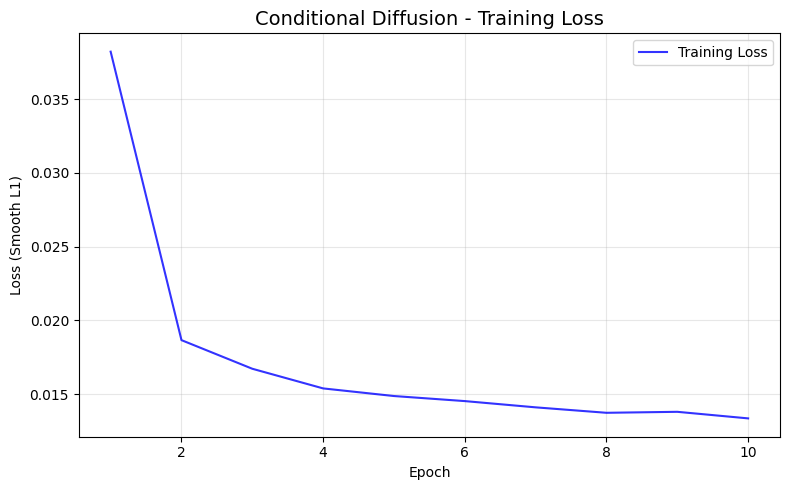

In [7]:
# Plot training loss (ConditionalGanStabilization-style)
def plot_loss_history(history):
    """Plot diffusion training loss over epochs"""
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.plot(history['epoch'], history['loss'], color='blue', linestyle='-', alpha=0.8, label='Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (Smooth L1)')
    ax.set_title('Conditional Diffusion - Training Loss', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_loss_history(train_history)

## Generation

For prompts I used a set of 16 labels 0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5. The results are meaningful and correspond to the prompts, providing recognizable items.

0it [00:00, ?it/s]

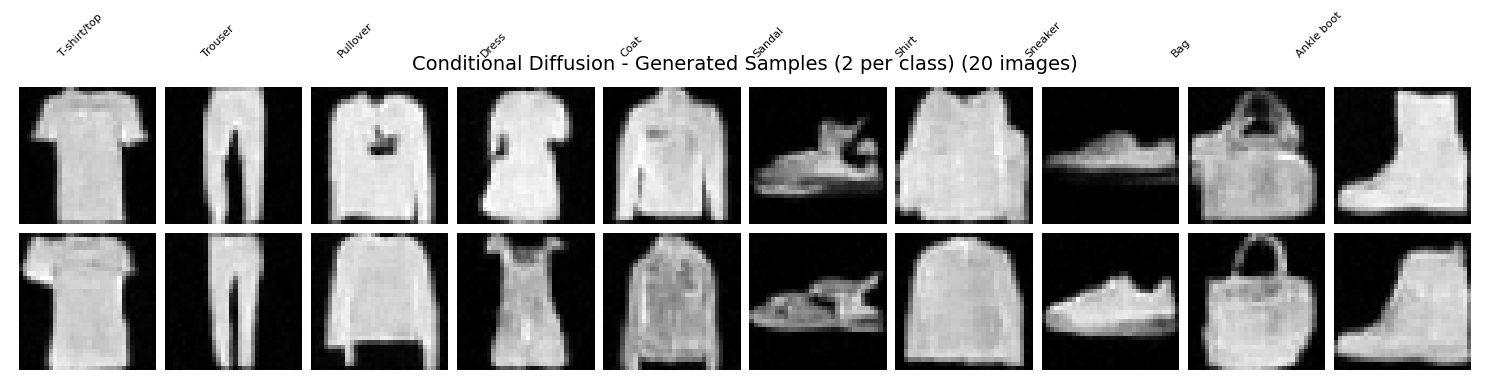

0it [00:00, ?it/s]

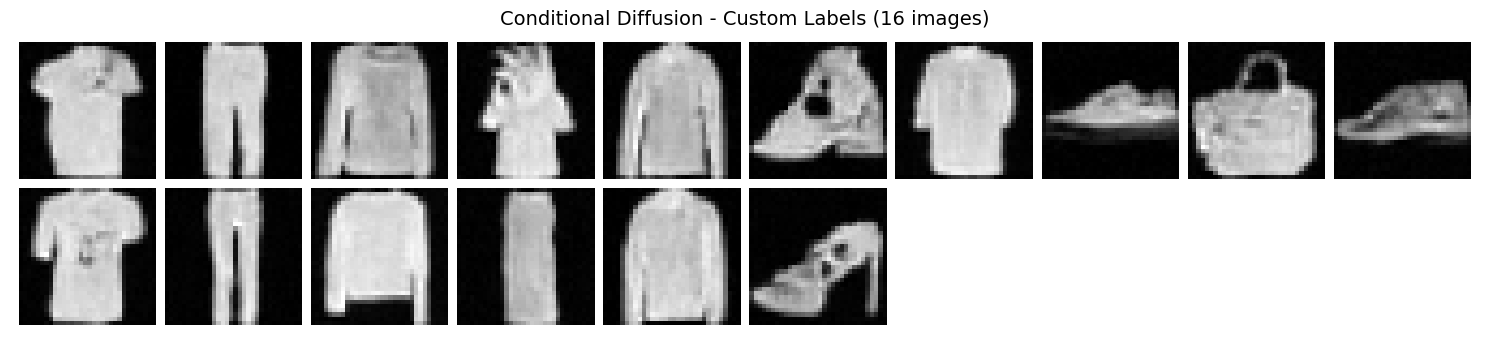

In [8]:
def display_generated_samples(model, diffusion, labels=None, title="Conditional Diffusion - Generated Samples"):
    """
    Display generated samples with class labels (ConditionalGanStabilization style).
    If labels is None, generates 2 samples per class (20 images).
    """
    num_classes = 10
    if labels is None:
        labels = torch.tensor(list(range(num_classes)) * 2, device=device)
        num_images = num_classes * 2
    else:
        labels = labels.to(device)
        num_images = len(labels)

    model.eval()
    samples = diffusion.sample(model, num_images, labels)
    samples = samples.float() / 255.0
    grid = make_grid(samples, nrow=num_classes, normalize=False, pad_value=1)

    plt.figure(figsize=(15, 4))
    grid_np = grid.permute(1, 2, 0).cpu().numpy()
    if grid_np.ndim == 3 and grid_np.shape[2] == 1:
        plt.imshow(grid_np.squeeze(-1), cmap='gray')
    elif grid_np.ndim == 3 and grid_np.shape[2] == 3:
        plt.imshow(grid_np)
    else:
        plt.imshow(grid_np.squeeze(), cmap='gray')
    plt.title(f"{title} ({num_images} images)", fontsize=14)
    plt.axis('off')
    # Add class labels below grid when using 2-per-class layout (10 columns)
    if num_images == num_classes * 2 and labels is not None:
        for i in range(num_classes):
            plt.text(i * 32 + 16, -5, class_names[i], ha='center', va='bottom', fontsize=8, rotation=45)
    plt.tight_layout()
    plt.show()
    model.train()

# Generate images: 2 per class (all 10 classes)
display_generated_samples(model, diffusion, title="Conditional Diffusion - Generated Samples (2 per class)")

# Custom label sequence
display_generated_samples(model, diffusion, labels=torch.tensor([0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5]).to(device),
                         title="Conditional Diffusion - Custom Labels")

## Conditioning Debug

Verifies that the model respects class labels: same noise with different labels should yield distinct class-specific outputs.

0it [00:00, ?it/s]

0it [00:00, ?it/s]

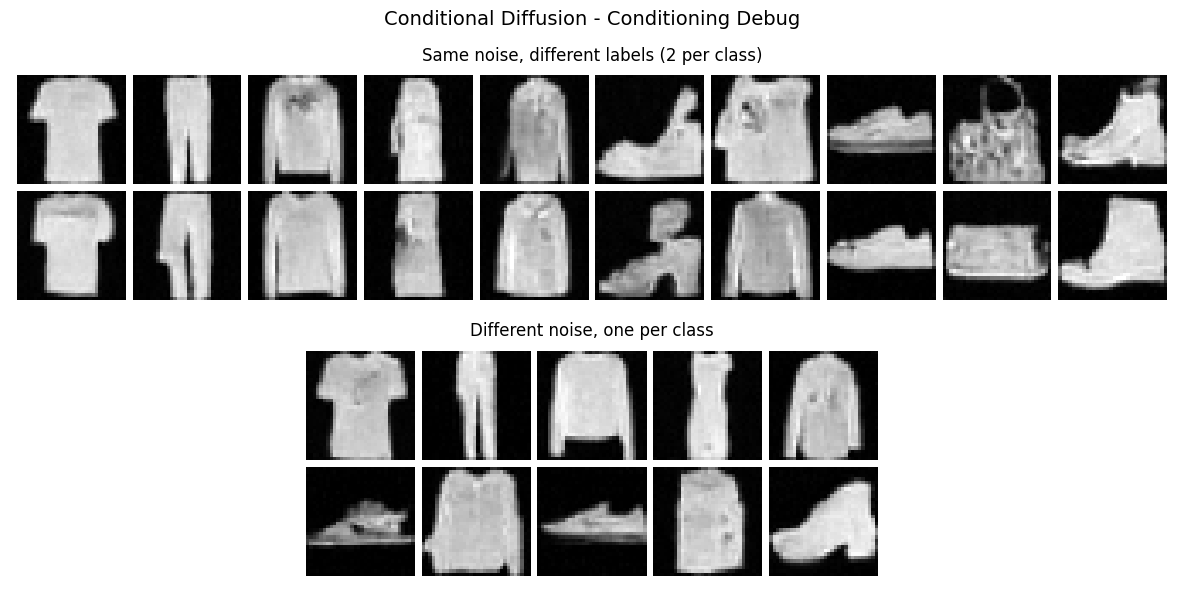

In [9]:
# Debug: verify class conditioning (ConditionalGanStabilization-style)
def debug_conditioning(model, diffusion):
    """
    Verify that the model respects class conditioning:
    - Same noise, different labels: should produce different-looking images per class
    - Different noise, same labels: should produce same-class but varied images
    """
    model.eval()
    num_classes = 10
    with torch.no_grad():
        # Same noise for all classes (different labels) - tests conditioning strength
        n_per = 2
        labels_same_noise = torch.tensor(list(range(num_classes)) * n_per, device=device)
        samples_same = diffusion.sample(model, num_classes * n_per, labels_same_noise)
        grid1 = make_grid(samples_same.float() / 255, nrow=num_classes, normalize=False, pad_value=1)

        # Different noise, one per class
        labels_diff = torch.tensor(list(range(num_classes)), device=device)
        samples_diff = diffusion.sample(model, num_classes, labels_diff)
        grid2 = make_grid(samples_diff.float() / 255, nrow=5, normalize=False, pad_value=1)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    for ax, grid, title in [(axes[0], grid1, "Same noise, different labels (2 per class)"),
                            (axes[1], grid2, "Different noise, one per class")]:
        g = grid.permute(1, 2, 0).cpu().numpy()
        if g.shape[2] == 1:
            ax.imshow(g.squeeze(-1), cmap='gray')
        else:
            ax.imshow(g)
        ax.set_title(title, fontsize=12)
        ax.axis('off')
    plt.suptitle("Conditional Diffusion - Conditioning Debug", fontsize=14)
    plt.tight_layout()
    plt.show()
    model.train()

debug_conditioning(model, diffusion)